In [455]:
#install the relevant packages
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
import os
from pathlib import Path
from matplotlib.colors import ListedColormap


In [456]:
#parameters
road_length = 250
cars = 50
buses = 5
max_speed = 5
num_steps = 200
pc_slow = 0.2
pb_slow = 0.1
stop_positions = [50, 100, 150, 200]
people = 0
max_passengers = 70


def parameterise(road_length, people, stop_positions, buses, cars, max_speed, max_passengers):
    road = np.zeros((road_length, 5), dtype=int)
    road[:, 1] = -1 #set all cells to empty
    road[:, 2] = -1 #set all types to none
    road[stop_positions, 2] = people
    road[:, 3] = 0 #set to carry people
    road[:, 4] = np.arange(0, road_length)


    bus_positions = np.random.choice(road_length, buses, replace=False)

    for pos in bus_positions:
        road[pos, 0] = np.random.randint(0, max_speed + 1)  # Random speed
        road[pos, 1] = -3  # bus type

    empty_positions = np.where(road[:, 1] == -1)[0]
    car_positions = np.random.choice(empty_positions, cars, replace=False)


    for pos in car_positions:
        road[pos, 0] = np.random.randint(0, max_speed + 1)  # Random speed
        road[pos, 1] = -2  # Car type
    
    return road


In [457]:

def initialise_copy(r):
    length = r.shape[0]
    new_road = np.zeros_like(r)
    new_road[:, 0] = 0 # set 0 speed
    new_road[:, 1] = -1 # set emtpy type
    new_road[:, 2] = -1 # set bus stop to none
    new_road[:, ]
    visited = np.zeros(road_length, dtype=bool) # check visited indices

    return length, new_road, visited



def update_road(r, step):

    length, new_road, visited = initialise_copy(r)

    i=0 
    while i < road_length:
        speed, vtype, people, passengers, positions = r[i]

        if vtype != -1 and not visited[i]:
            if vtype < -2:

                visited[i] = True
                if speed < max_speed:
                    speed += 1
                if speed > 0 and np.random.rand() < pb_slow:
                    speed -= 1
                if people == -1 or people == 0  or passengers == max_passengers:
                    distance = 1
                    while distance <= speed:
                        idx = (i + distance) % road_length
                        if r[idx, 1] != -1 or new_road[idx, 1] != -1:
                            break
                        if r[idx, 2] != -1 and r[idx, 2] != 0:
                            distance +=1
                            break
                        distance += 1
                    distance -= 1
                    move_speed = min(speed, distance)
                    new_pos = (i + move_speed) % road_length

                    new_road[new_pos, 0] = move_speed
                    new_road[new_pos, 1] = -3
                    new_road[new_pos, 2] = r[new_pos, 2]
                else:
                    if step % 4 == 0:
                        new_road[i, 0] = 0
                        new_road[i, 2] = r[i, 2] - 1
                        new_road[i, 1] = -4
                        new_road[i, 3] = r[i, 3] + 1
                    else:
                        new_road[i, 0] = 0
                        new_road[i, 2] = r[i, 2]
                        new_road[i, 1] = -4
                        new_road[i, 3] = r[i, 3]                       

                i +=1
                continue
            elif vtype == -2:
                visited[i] = True

                if speed < max_speed:
                    speed += 2
                if speed > 0 and np.random.rand() < pc_slow:
                    speed -= 2

                distance = 1
                while distance <= speed:
                    idx = (i + distance) % road_length
                    if r[idx, 1] != -1 or new_road[idx, 1] != -1:
                        break
                    distance += 1
                distance -= 1

                move_speed = min(speed, distance)
                new_pos = (i + move_speed) % road_length

                new_road[new_pos, 0] = move_speed
                new_road[new_pos, 1] = -2
                new_road[new_pos, 2] = r[i, 2]

                i += 1
                continue
        else:
            new_road[i, 2] = r[i, 2]
            i += 1

        for pos in stop_positions:
            if new_road[pos, 1] != -4:      # if no bus unloading here
                new_road[pos, 2] = r[pos, 2]
            if step % 10 == 0:
                new_road[pos, 2] = r[pos, 2] + 1

    # ============================
    # PHASE 2: OVERTAKING PASS
    # ============================

    final_road = new_road.copy()

    for i in range(road_length):

        vtype = new_road[i, 1]

        # Only moving vehicles can overtake (cars -2, buses -3)
        if vtype not in (-2, -3):
            continue

        next1 = (i + 1) % road_length
        next2 = (i + 2) % road_length

        # Check if next cell is a stopped bus at a stop
        is_stopped_bus_at_stop = (
            new_road[next1, 1] == -4 and
            new_road[next1, 2] > 0
        )

        # Check if overtaking space is free in FINAL road
        is_overtake_space_free = (final_road[next2, 1] == -1)

        if not (is_stopped_bus_at_stop and is_overtake_space_free):
            continue

        # --- PROBABILITY CHECK ---
        if vtype == -3:  # bus
            if np.random.rand() > 0.2:
                continue  # bus decides NOT to overtake

        # Move vehicle to next2
        final_road[next2, 0] = new_road[i, 0]      # speed
        final_road[next2, 1] = vtype               # keep type (-2 or -3)
        final_road[next2, 2] = new_road[next2, 2]  # preserve stop
        final_road[next2, 3] = new_road[i, 3]      # passengers

        # Clear old cell
        final_road[i, 0] = 0
        final_road[i, 1] = -1
        final_road[i, 2] = new_road[i, 2]          # restore stop if needed
        final_road[i, 3] = 0
    final_road[:, 4] = r[:, 4]
    # Count buses after overtaking
    num_buses = np.sum(final_road[:,1] == -3) + np.sum(final_road[:,1] == -4)

    return final_road


def average_bus_density(r):
    # Identify buses
    bus_mask = (r[:,1] == -3) | (r[:,1] == -4)
    bus_positions = r[bus_mask, 4]

    num_buses = len(bus_positions)

    if num_buses == 0:
        return 0, 0   # no buses, no density, no bunching

    # Sort positions around the ring
    bus_positions = np.sort(bus_positions)
    # Density
    density = num_buses / road_length

    # Headways (circular)
    headways = np.diff(bus_positions, append=bus_positions[0] + road_length)
    # Bunching parameter = coefficient of variation
    bunching = np.std(headways) / np.mean(headways)

    return bunching

            

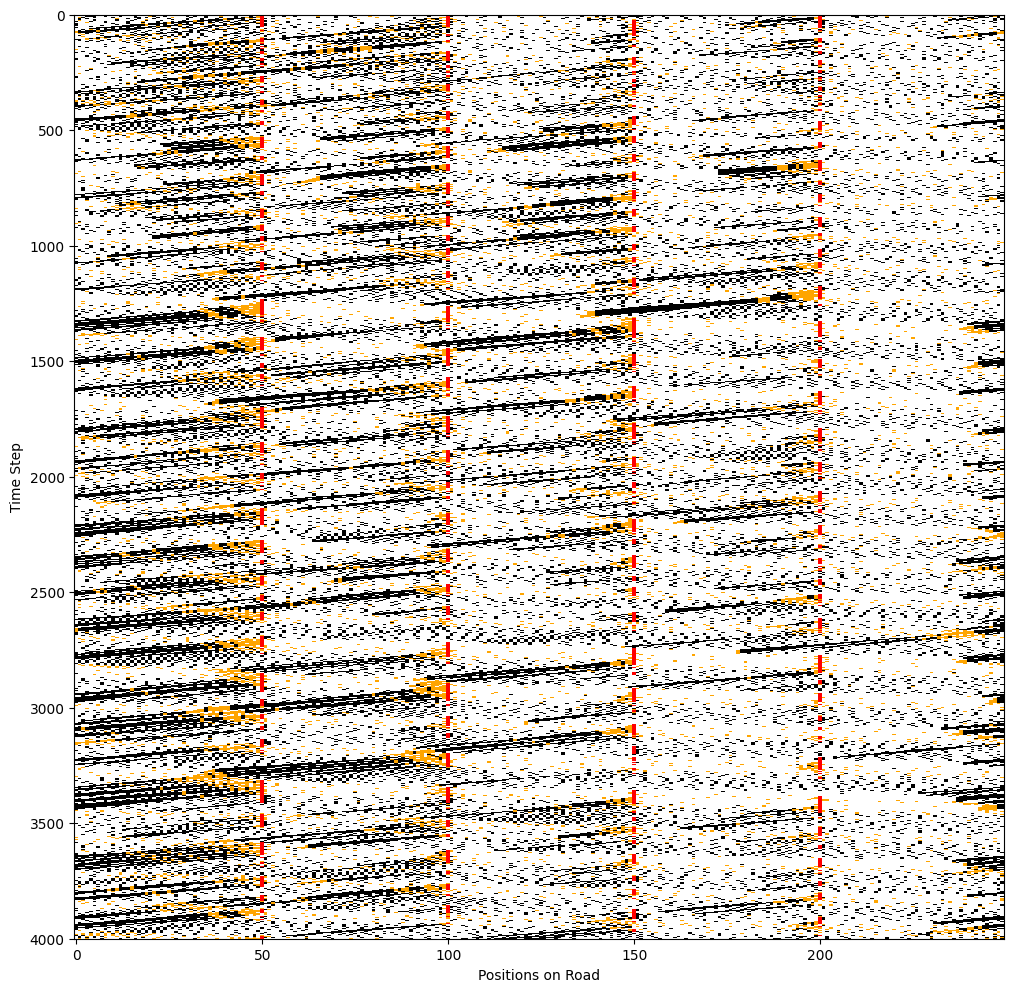

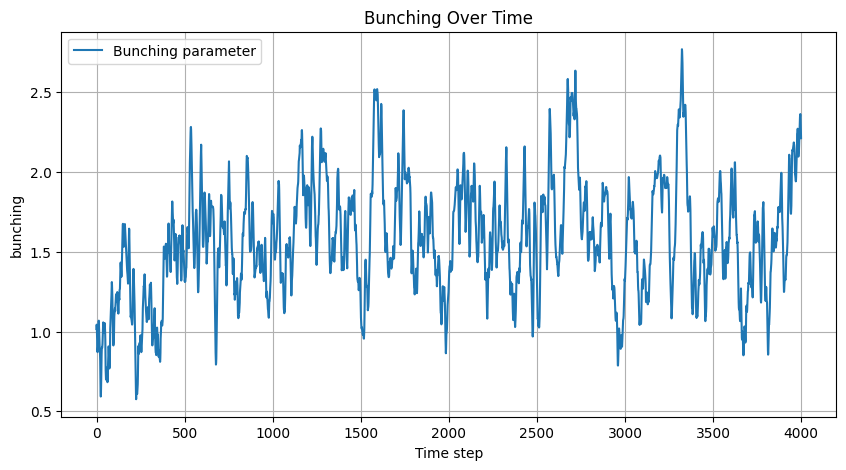

'\nimage_filenames = []\nfor i, r in enumerate(road_display):\n    ax.clear()\n    ax.imshow([r], cmap=cmap, aspect="auto")\n    ax.set_title(f"Time Step {i}")\n    ax.set_xlabel("Position on Road")\n    ax.set_yticks([])\n    save_path = f"traffic_{i}.png"\n    fig.savefig(save_path, dpi=300)\n    image_filenames.append(save_path)\n\n\ndef create_gif(image_filenames, output_filename="traffic.gif", fps=3):\n\n    Creates an animated GIF from a list of image filenames.\n\n    from PIL import Image\n\n    images = [Image.open(filename) for filename in image_filenames]\n    images[0].save(\n        output_filename,\n        save_all=True,\n        append_images=images[1:],\n        duration=1000 // fps,\n        loop=0,\n    )\n\ncreate_gif(image_filenames, output_filename="traffic.gif", fps=3)\n\nfrom IPython.display import Image\nImage(filename="traffic.gif")\n'

In [458]:

average_slopes = []
from sklearn.linear_model import LinearRegression

for i in range(2, 15) :
    road = parameterise(road_length, 5, stop_positions, i, 50, 3, 40)
    road_history = [road.copy()]
    bunchings = []
    for j in range(20):
        j_average = []
        for step in range(num_steps):
            road = update_road(road, step)
            bunching  = average_bus_density(road)
            bunchings.append(bunching)
            road_history.append(road.copy())

            t = np.arange(len(bunchings)).reshape(-1, 1)
            y = np.array(bunchings)

            model = LinearRegression().fit(t, y)
            slope = model.coef_[0]
            j_average.append(slope)
            intercept = model.intercept_
        average_slopes.append(np.mean(j_average))

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_xlabel("Positions on Road")
ax.set_ylabel("Time Step")
road_display = []
for state in road_history:
    types = state[:, 1]  # Extract vehicle type column

    # Map types to display codes
    display_state = np.where(types == -2, 1,          # empty → white
                 np.where(types == -3, 2,          # car → black
                 np.where(types == -4, 3, 0)))     # Stopped bus → 3 (red), Empty → 0

    road_display.append(display_state)

road_display = np.array(road_display)

# Custom colormap: 0=white, 1=black, 2=orange, 3=red
cmap = ListedColormap(["white", "black", "orange", "red"])

im = ax.imshow(road_display, cmap=cmap, interpolation="none", aspect="auto")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(bunchings, label="Bunching parameter")
plt.xlabel("Time step")
plt.ylabel("bunching")
plt.title("Bunching Over Time")
plt.legend()
plt.grid(True)
plt.show()

"""
image_filenames = []
for i, r in enumerate(road_display):
    ax.clear()
    ax.imshow([r], cmap=cmap, aspect="auto")
    ax.set_title(f"Time Step {i}")
    ax.set_xlabel("Position on Road")
    ax.set_yticks([])
    save_path = f"traffic_{i}.png"
    fig.savefig(save_path, dpi=300)
    image_filenames.append(save_path)


def create_gif(image_filenames, output_filename="traffic.gif", fps=3):
    
    Creates an animated GIF from a list of image filenames.
    
    from PIL import Image

    images = [Image.open(filename) for filename in image_filenames]
    images[0].save(
        output_filename,
        save_all=True,
        append_images=images[1:],
        duration=1000 // fps,
        loop=0,
    )

create_gif(image_filenames, output_filename="traffic.gif", fps=3)

from IPython.display import Image
Image(filename="traffic.gif")
"""

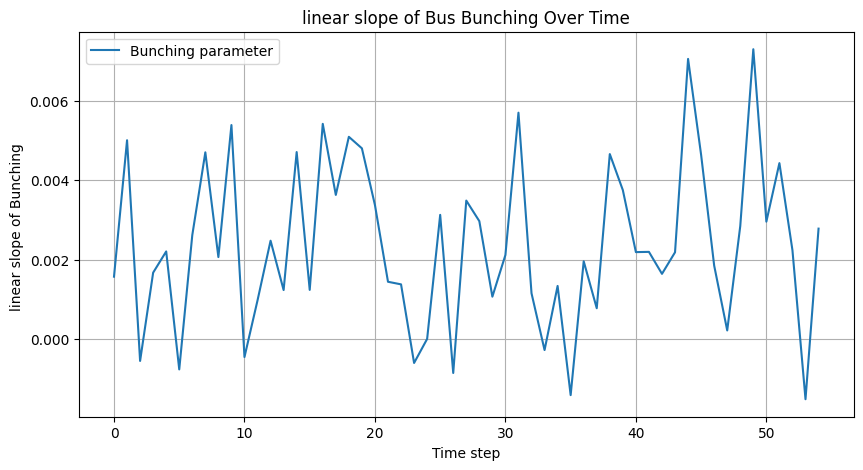

In [459]:
plt.figure(figsize=(10,5))
plt.plot(slopes, label="Bunching parameter")
plt.xlabel("Time step")
plt.ylabel("linear slope of Bunching ")
plt.title("linear slope of Bus Bunching Over Time")
plt.legend()
plt.grid(True)
plt.show()